<a href="https://colab.research.google.com/github/maneesram134-collab/-Project-A-Exploratory-Data-Analysis-EDA-on-a-Titanic-or-Iris-dataset./blob/main/Project_A_Exploratory_Data_Analysis_(EDA)_on_a_Titanic_or_Iris_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# CELL 1: IMPORT ALL LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For interactive visualizations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# For statistical tests
from scipy import stats

print(" All libraries imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 NumPy version: {np.__version__}")

 All libraries imported successfully!
📊 Pandas version: 2.1.4
📈 NumPy version: 1.26.4


In [2]:
pip install plotly


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================
# CELL 2: LOAD AND EXPLORE DATASET
# ============================================
# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("="*60)
print("TITANIC DATASET - INITIAL EXPLORATION")
print("="*60)

# Basic info
print(f"\n📌 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📌 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

# First 5 rows
print("\n📌 First 5 rows:")
print(df.head())

# Last 5 rows
print("\n📌 Last 5 rows:")
print(df.tail())

# Random sample
print("\n📌 Random 5 samples:")
print(df.sample(5))

# Data types
print("\n📌 Data Types:")
print(df.dtypes)

TITANIC DATASET - INITIAL EXPLORATION

📌 Dataset Shape: 891 rows × 12 columns

📌 Column Names:
   1. PassengerId
   2. Survived
   3. Pclass
   4. Name
   5. Sex
   6. Age
   7. SibSp
   8. Parch
   9. Ticket
   10. Fare
   11. Cabin
   12. Embarked

📌 First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  


In [4]:
# ============================================
# CELL 3: COMPREHENSIVE DATA INFORMATION
# ============================================
print("="*60)
print("COMPREHENSIVE DATA INFORMATION")
print("="*60)

# Detailed info
print("\n📌 Dataset Info:")
df.info()

# Statistical summary
print("\n📌 Statistical Summary (Numerical Features):")
print(df.describe())

print("\n📌 Statistical Summary (Categorical Features):")
print(df.describe(include=['O']))

# Missing values count
print("\n📌 Missing Values Count:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

# Unique values in each column
print("\n📌 Unique Values in Each Column:")
for col in df.columns:
    print(f"   {col}: {df[col].nunique()} unique values")

COMPREHENSIVE DATA INFORMATION

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

📌 Statistical Summary (Numerical Features):
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446

In [5]:
# ============================================
# CELL 4: DATA CLEANING AND PREPROCESSING
# ============================================
print("="*60)
print("DATA CLEANING AND PREPROCESSING")
print("="*60)

# Create a cleaned copy
df_clean = df.copy()

# 1. Handle Missing Age - Fill with median based on Pclass and Sex
print("\n📌 1. Handling Missing Age Values...")
print(f"   Before: {df_clean['Age'].isnull().sum()} missing values")

# Group by Pclass and Sex, then fill with median
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# If still any missing, fill with overall median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
print(f"   After: {df_clean['Age'].isnull().sum()} missing values")

# 2. Handle Embarked - Fill with mode
print(f"\n📌 2. Handling Missing Embarked Values...")
print(f"   Before: {df_clean['Embarked'].isnull().sum()} missing values")
print(f"   Mode value: {df_clean['Embarked'].mode()[0]}")

df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
print(f"   After: {df_clean['Embarked'].isnull().sum()} missing values")

# 3. Handle Cabin - Too many missing, create new feature
print(f"\n📌 3. Handling Cabin Feature...")
print(f"   Before: {df_clean['Cabin'].isnull().sum()} missing values")
print(f"   Creating 'Has_Cabin' feature...")

df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)
df_clean.drop('Cabin', axis=1, inplace=True)
print(f"   After: 'Cabin' column removed, 'Has_Cabin' created")
print(f"   Passengers with cabin: {df_clean['Has_Cabin'].sum()} ({df_clean['Has_Cabin'].mean()*100:.2f}%)")

# 4. Create Family Size feature
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch'] + 1
print(f"\n📌 4. Created Family Size feature")
print(f"   Min family size: {df_clean['Family_Size'].min()}")
print(f"   Max family size: {df_clean['Family_Size'].max()}")
print(f"   Average family size: {df_clean['Family_Size'].mean():.2f}")

# 5. Create Is_Alone feature
df_clean['Is_Alone'] = (df_clean['Family_Size'] == 1).astype(int)
print(f"\n📌 5. Created Is_Alone feature")
print(f"   Passengers alone: {df_clean['Is_Alone'].sum()} ({df_clean['Is_Alone'].mean()*100:.2f}%)")

# 6. Extract Title from Name
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(f"\n📌 6. Extracted Titles from Names")
print(f"   Unique titles: {df_clean['Title'].nunique()}")
print(f"   Title distribution:")
print(df_clean['Title'].value_counts())

# Simplify titles
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Mlle': 'Miss',
    'Countess': 'Rare',
    'Ms': 'Miss',
    'Lady': 'Rare',
    'Jonkheer': 'Rare',
    'Don': 'Rare',
    'Dona': 'Rare',
    'Mme': 'Mrs',
    'Capt': 'Rare',
    'Sir': 'Rare'
}
df_clean['Title_Simplified'] = df_clean['Title'].map(title_mapping).fillna('Rare')
print(f"\n📌 Simplified titles:")
print(df_clean['Title_Simplified'].value_counts())

# 7. Create Age Groups
df_clean['Age_Group'] = pd.cut(df_clean['Age'],
                                 bins=[0, 12, 18, 30, 50, 80],
                                 labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
print(f"\n📌 7. Created Age Groups")
print(f"   Age group distribution:")
print(df_clean['Age_Group'].value_counts())

# 8. Create Fare Groups
df_clean['Fare_Group'] = pd.qcut(df_clean['Fare'].clip(lower=0.01),
                                   q=4,
                                   labels=['Low', 'Medium', 'High', 'Very High'])
print(f"\n📌 8. Created Fare Groups")
print(f"   Fare group distribution:")
print(df_clean['Fare_Group'].value_counts())

print("\n✅ Data cleaning and feature engineering complete!")
print(f"📌 Final dataset shape: {df_clean.shape}")

DATA CLEANING AND PREPROCESSING

📌 1. Handling Missing Age Values...
   Before: 177 missing values
   After: 0 missing values

📌 2. Handling Missing Embarked Values...
   Before: 2 missing values
   Mode value: S
   After: 0 missing values

📌 3. Handling Cabin Feature...
   Before: 687 missing values
   Creating 'Has_Cabin' feature...
   After: 'Cabin' column removed, 'Has_Cabin' created
   Passengers with cabin: 204 (22.90%)

📌 4. Created Family Size feature
   Min family size: 1
   Max family size: 11
   Average family size: 1.90

📌 5. Created Is_Alone feature
   Passengers alone: 537 (60.27%)

📌 6. Extracted Titles from Names
   Unique titles: 17
   Title distribution:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

📌 Simplified t

UNIVARIATE ANALYSIS - SURVIVAL DISTRIBUTION


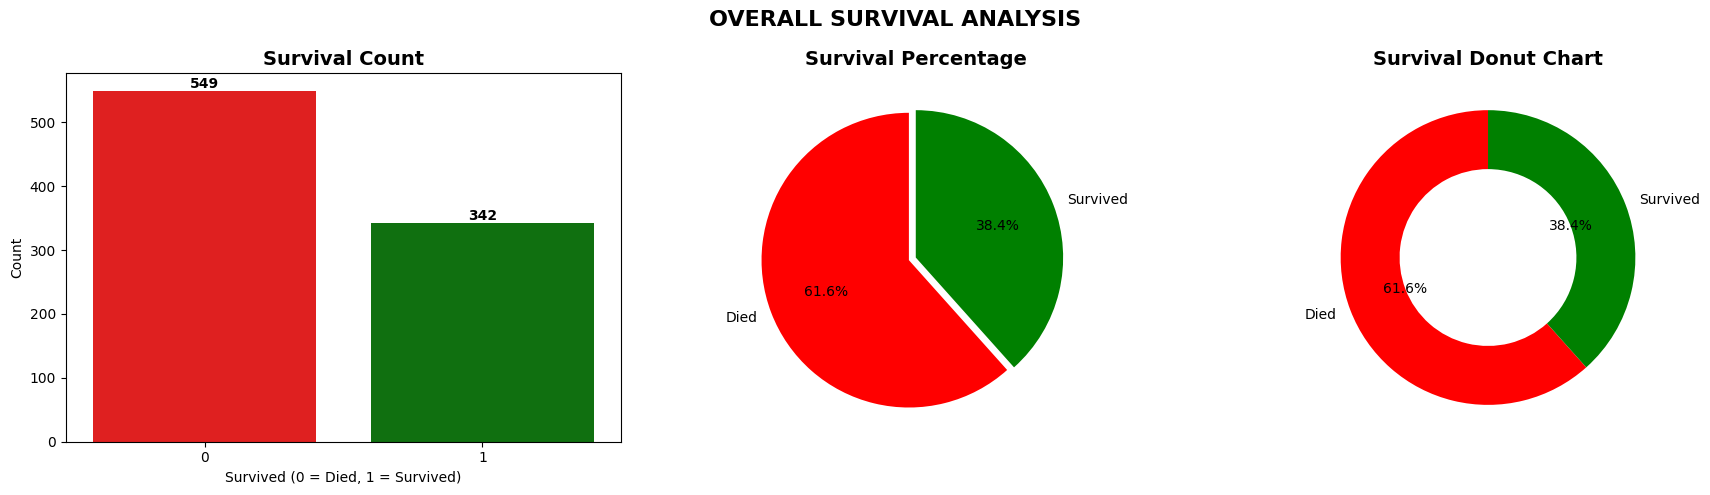

📊 Survival Rate: 38.38%
📊 Total Survivors: 342
📊 Total Casualties: 549


In [6]:
# ============================================
# CELL 5: SURVIVAL ANALYSIS - UNIVARIATE
# ============================================
print("="*60)
print("UNIVARIATE ANALYSIS - SURVIVAL DISTRIBUTION")
print("="*60)

# SCREENSHOT 1: Overall Survival
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count plot
ax1 = axes[0]
survival_counts = df_clean['Survived'].value_counts()
sns.barplot(x=survival_counts.index, y=survival_counts.values, ax=ax1, palette=['red', 'green'])
ax1.set_title('Survival Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Survived (0 = Died, 1 = Survived)')
ax1.set_ylabel('Count')
for i, v in enumerate(survival_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
ax2 = axes[1]
survival_percent = df_clean['Survived'].value_counts(normalize=True) * 100
ax2.pie(survival_percent, labels=['Died', 'Survived'], autopct='%1.1f%%',
        colors=['red', 'green'], startangle=90, explode=(0.05, 0))
ax2.set_title('Survival Percentage', fontsize=14, fontweight='bold')

# Donut chart
ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(survival_percent, labels=['Died', 'Survived'],
                                     autopct='%1.1f%%', colors=['red', 'green'],
                                     startangle=90, wedgeprops=dict(width=0.4))
ax3.set_title('Survival Donut Chart', fontsize=14, fontweight='bold')

plt.suptitle('OVERALL SURVIVAL ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"📊 Survival Rate: {df_clean['Survived'].mean()*100:.2f}%")
print(f"📊 Total Survivors: {df_clean['Survived'].sum()}")
print(f"📊 Total Casualties: {len(df_clean) - df_clean['Survived'].sum()}")

SURVIVAL ANALYSIS BY GENDER


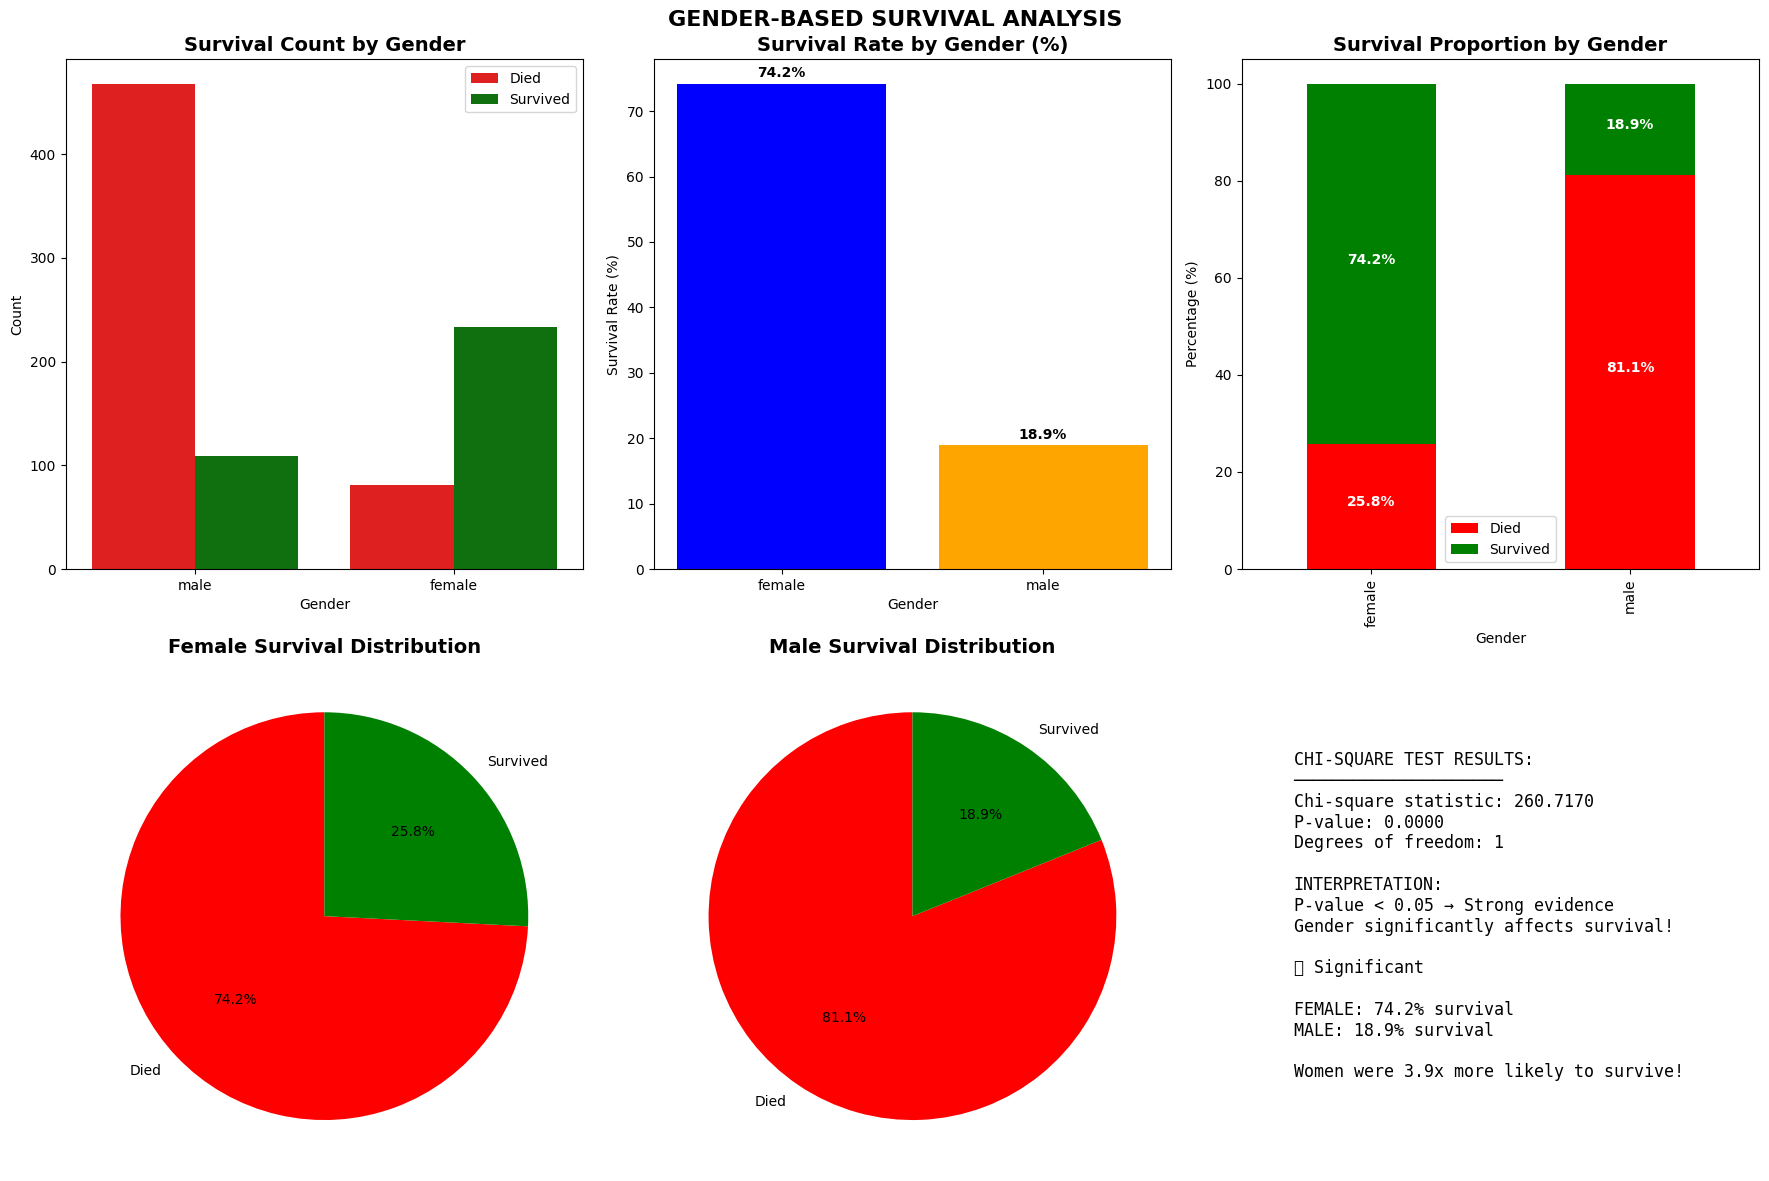


📊 Female Survival Rate: 74.20%
📊 Male Survival Rate: 18.89%
📊 Women were 3.93x more likely to survive


In [7]:
# ============================================
# CELL 6: SURVIVAL BY GENDER
# ============================================
print("="*60)
print("SURVIVAL ANALYSIS BY GENDER")
print("="*60)

# SCREENSHOT 2: Gender Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Count plot by gender
ax1 = axes[0, 0]
sns.countplot(x='Sex', hue='Survived', data=df_clean, ax=ax1, palette=['red', 'green'])
ax1.set_title('Survival Count by Gender', fontsize=14, fontweight='bold')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Count')
ax1.legend(['Died', 'Survived'])

# Survival percentage by gender
ax2 = axes[0, 1]
gender_survival = df_clean.groupby('Sex')['Survived'].mean() * 100
bars = ax2.bar(gender_survival.index, gender_survival.values, color=['blue', 'orange'])
ax2.set_title('Survival Rate by Gender (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Survival Rate (%)')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

# Proportion comparison
ax3 = axes[0, 2]
gender_counts = df_clean.groupby(['Sex', 'Survived']).size().unstack()
gender_percent = gender_counts.div(gender_counts.sum(axis=1), axis=0) * 100
gender_percent.plot(kind='bar', stacked=True, ax=ax3, color=['red', 'green'])
ax3.set_title('Survival Proportion by Gender', fontsize=14, fontweight='bold')
ax3.set_xlabel('Gender')
ax3.set_ylabel('Percentage (%)')
ax3.legend(['Died', 'Survived'])
for i, (index, row) in enumerate(gender_percent.iterrows()):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 5:  # Only show text if segment is large enough
            ax3.text(i, cumulative + val/2, f'{val:.1f}%',
                    ha='center', fontweight='bold', color='white')
        cumulative += val

# Pie charts for each gender
ax4 = axes[1, 0]
female_survival = df_clean[df_clean['Sex'] == 'female']['Survived'].value_counts(normalize=True) * 100
ax4.pie(female_survival, labels=['Died', 'Survived'], autopct='%1.1f%%',
        colors=['red', 'green'], startangle=90)
ax4.set_title('Female Survival Distribution', fontsize=14, fontweight='bold')

ax5 = axes[1, 1]
male_survival = df_clean[df_clean['Sex'] == 'male']['Survived'].value_counts(normalize=True) * 100
ax5.pie(male_survival, labels=['Died', 'Survived'], autopct='%1.1f%%',
        colors=['red', 'green'], startangle=90)
ax5.set_title('Male Survival Distribution', fontsize=14, fontweight='bold')

# Statistical test
ax6 = axes[1, 2]
ax6.axis('off')
contingency_table = pd.crosstab(df_clean['Sex'], df_clean['Survived'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

info_text = f"""
CHI-SQUARE TEST RESULTS:
─────────────────────
Chi-square statistic: {chi2:.4f}
P-value: {p_value:.4f}
Degrees of freedom: {dof}

INTERPRETATION:
P-value < 0.05 → Strong evidence
Gender significantly affects survival!

{'✅ Significant' if p_value < 0.05 else '❌ Not Significant'}

FEMALE: {gender_survival['female']:.1f}% survival
MALE: {gender_survival['male']:.1f}% survival

Women were {(gender_survival['female']/gender_survival['male']):.1f}x more likely to survive!
"""
ax6.text(0.1, 0.5, info_text, fontsize=12, va='center', fontfamily='monospace')

plt.suptitle('GENDER-BASED SURVIVAL ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Female Survival Rate: {gender_survival['female']:.2f}%")
print(f"📊 Male Survival Rate: {gender_survival['male']:.2f}%")
print(f"📊 Women were {gender_survival['female']/gender_survival['male']:.2f}x more likely to survive")

SURVIVAL ANALYSIS BY PASSENGER CLASS


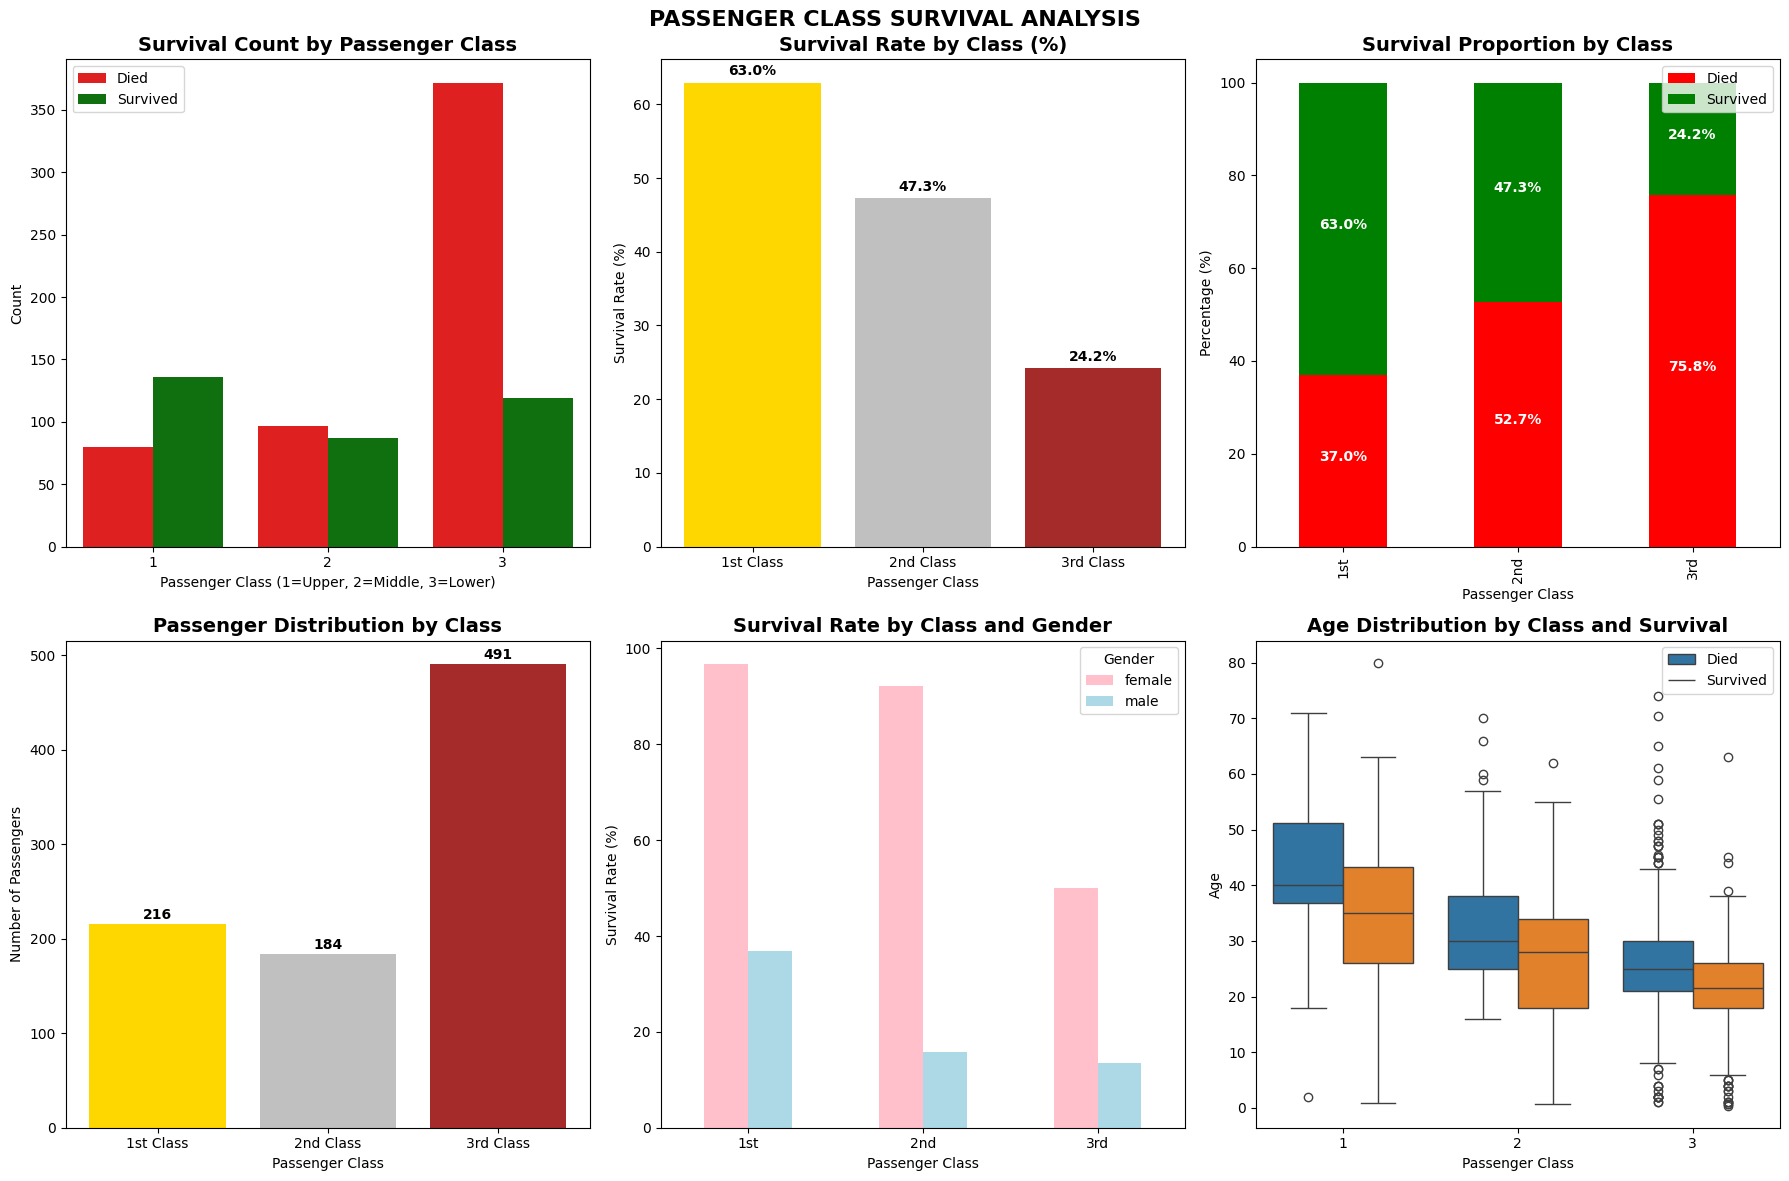


📊 1st Class Survival Rate: 62.96%
📊 2nd Class Survival Rate: 47.28%
📊 3rd Class Survival Rate: 24.24%
📊 1st Class passengers were 2.60x more likely to survive than 3rd Class


In [8]:
# ============================================
# CELL 7: SURVIVAL BY PASSENGER CLASS
# ============================================
print("="*60)
print("SURVIVAL ANALYSIS BY PASSENGER CLASS")
print("="*60)

# SCREENSHOT 3: Class Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Count plot by class
ax1 = axes[0, 0]
sns.countplot(x='Pclass', hue='Survived', data=df_clean, ax=ax1, palette=['red', 'green'])
ax1.set_title('Survival Count by Passenger Class', fontsize=14, fontweight='bold')
ax1.set_xlabel('Passenger Class (1=Upper, 2=Middle, 3=Lower)')
ax1.set_ylabel('Count')
ax1.legend(['Died', 'Survived'])

# Survival percentage by class
ax2 = axes[0, 1]
class_survival = df_clean.groupby('Pclass')['Survived'].mean() * 100
bars = ax2.bar(['1st Class', '2nd Class', '3rd Class'], class_survival.values,
               color=['gold', 'silver', 'brown'])
ax2.set_title('Survival Rate by Class (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Passenger Class')
ax2.set_ylabel('Survival Rate (%)')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

# Proportion comparison
ax3 = axes[0, 2]
class_counts = df_clean.groupby(['Pclass', 'Survived']).size().unstack()
class_percent = class_counts.div(class_counts.sum(axis=1), axis=0) * 100
class_percent.plot(kind='bar', stacked=True, ax=ax3, color=['red', 'green'])
ax3.set_title('Survival Proportion by Class', fontsize=14, fontweight='bold')
ax3.set_xlabel('Passenger Class')
ax3.set_ylabel('Percentage (%)')
ax3.legend(['Died', 'Survived'])
ax3.set_xticklabels(['1st', '2nd', '3rd'])
for i, (index, row) in enumerate(class_percent.iterrows()):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 5:
            ax3.text(i, cumulative + val/2, f'{val:.1f}%',
                    ha='center', fontweight='bold', color='white')
        cumulative += val

# Class distribution
ax4 = axes[1, 0]
class_counts = df_clean['Pclass'].value_counts().sort_index()
bars = ax4.bar(['1st Class', '2nd Class', '3rd Class'], class_counts.values,
               color=['gold', 'silver', 'brown'])
ax4.set_title('Passenger Distribution by Class', fontsize=14, fontweight='bold')
ax4.set_xlabel('Passenger Class')
ax4.set_ylabel('Number of Passengers')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', fontweight='bold')

# Class + Gender interaction
ax5 = axes[1, 1]
class_gender = df_clean.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
class_gender.unstack().plot(kind='bar', ax=ax5, color=['pink', 'lightblue'])
ax5.set_title('Survival Rate by Class and Gender', fontsize=14, fontweight='bold')
ax5.set_xlabel('Passenger Class')
ax5.set_ylabel('Survival Rate (%)')
ax5.set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
ax5.legend(title='Gender')

# Class + Age boxplot
ax6 = axes[1, 2]
sns.boxplot(x='Pclass', y='Age', hue='Survived', data=df_clean, ax=ax6)
ax6.set_title('Age Distribution by Class and Survival', fontsize=14, fontweight='bold')
ax6.set_xlabel('Passenger Class')
ax6.set_ylabel('Age')
ax6.legend(['Died', 'Survived'])

plt.suptitle('PASSENGER CLASS SURVIVAL ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 1st Class Survival Rate: {class_survival[1]:.2f}%")
print(f"📊 2nd Class Survival Rate: {class_survival[2]:.2f}%")
print(f"📊 3rd Class Survival Rate: {class_survival[3]:.2f}%")
print(f"📊 1st Class passengers were {class_survival[1]/class_survival[3]:.2f}x more likely to survive than 3rd Class")

AGE AND FARE DISTRIBUTION ANALYSIS


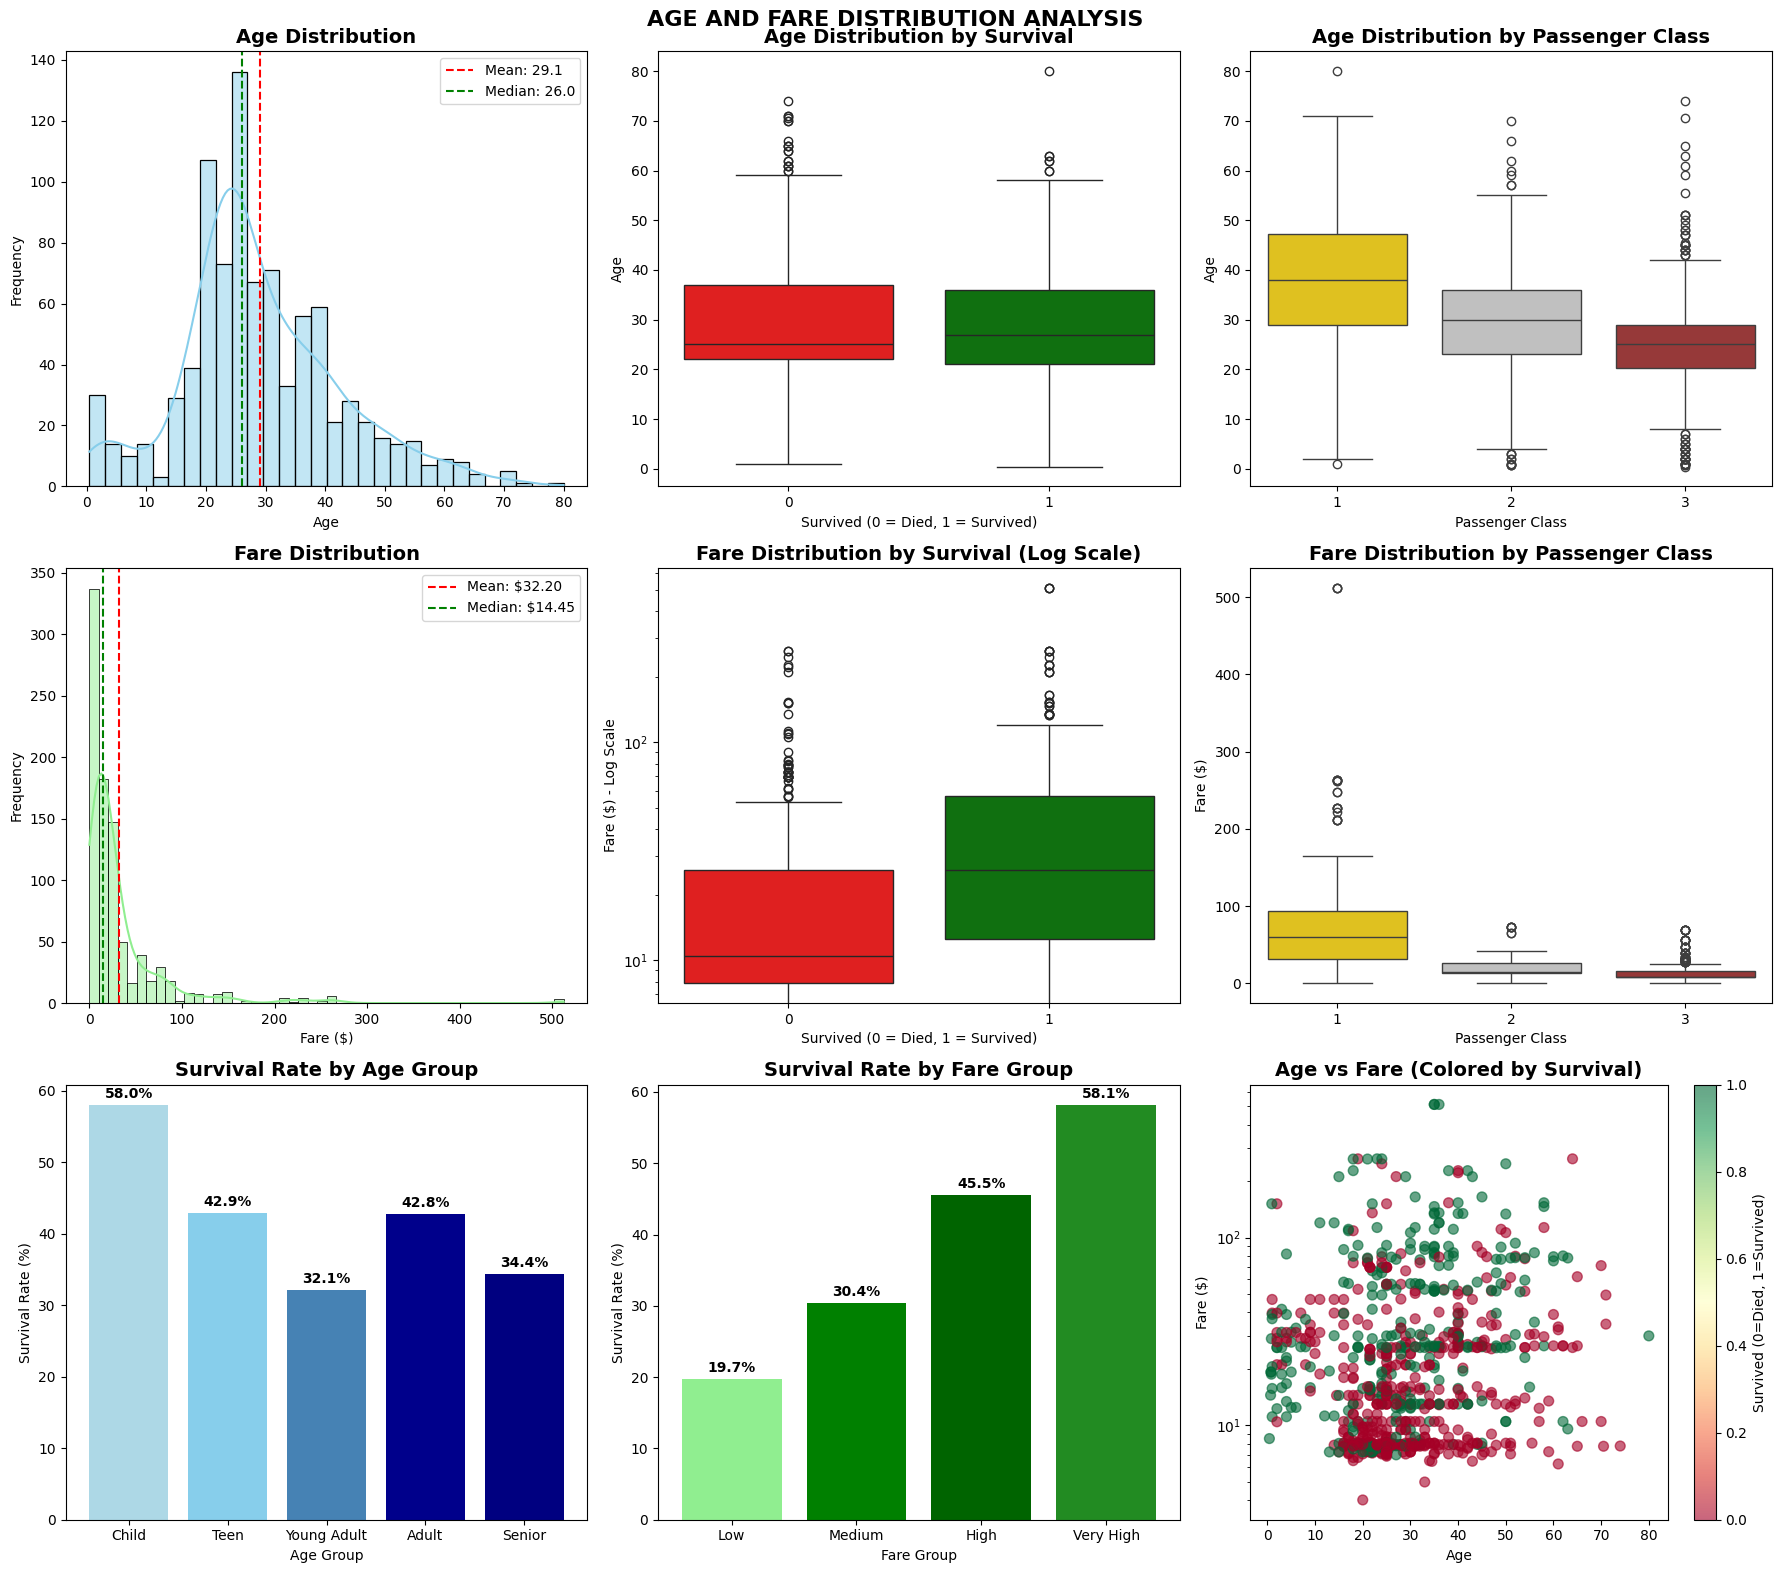


📊 Average Age of Survivors: 28.11
📊 Average Age of Non-Survivors: 29.74
📊 Average Fare of Survivors: $48.40
📊 Average Fare of Non-Survivors: $22.12


In [9]:
# ============================================
# CELL 8: AGE AND FARE DISTRIBUTIONS
# ============================================
print("="*60)
print("AGE AND FARE DISTRIBUTION ANALYSIS")
print("="*60)

# SCREENSHOT 4: Age and Fare Analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# Age distribution
ax1 = axes[0, 0]
sns.histplot(df_clean['Age'], bins=30, kde=True, ax=ax1, color='skyblue')
ax1.axvline(df_clean['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Age"].mean():.1f}')
ax1.axvline(df_clean['Age'].median(), color='green', linestyle='--', label=f'Median: {df_clean["Age"].median():.1f}')
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.legend()

# Age by survival
ax2 = axes[0, 1]
sns.boxplot(x='Survived', y='Age', data=df_clean, ax=ax2, palette=['red', 'green'])
ax2.set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
ax2.set_xlabel('Survived (0 = Died, 1 = Survived)')
ax2.set_ylabel('Age')

# Age by class
ax3 = axes[0, 2]
sns.boxplot(x='Pclass', y='Age', data=df_clean, ax=ax3, palette=['gold', 'silver', 'brown'])
ax3.set_title('Age Distribution by Passenger Class', fontsize=14, fontweight='bold')
ax3.set_xlabel('Passenger Class')
ax3.set_ylabel('Age')

# Fare distribution
ax4 = axes[1, 0]
sns.histplot(df_clean['Fare'], bins=50, kde=True, ax=ax4, color='lightgreen')
ax4.axvline(df_clean['Fare'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["Fare"].mean():.2f}')
ax4.axvline(df_clean['Fare'].median(), color='green', linestyle='--', label=f'Median: ${df_clean["Fare"].median():.2f}')
ax4.set_title('Fare Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Fare ($)')
ax4.set_ylabel('Frequency')
ax4.legend()

# Fare by survival (log scale)
ax5 = axes[1, 1]
sns.boxplot(x='Survived', y='Fare', data=df_clean, ax=ax5, palette=['red', 'green'])
ax5.set_yscale('log')
ax5.set_title('Fare Distribution by Survival (Log Scale)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Survived (0 = Died, 1 = Survived)')
ax5.set_ylabel('Fare ($) - Log Scale')

# Fare by class
ax6 = axes[1, 2]
sns.boxplot(x='Pclass', y='Fare', data=df_clean, ax=ax6, palette=['gold', 'silver', 'brown'])
ax6.set_title('Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
ax6.set_xlabel('Passenger Class')
ax6.set_ylabel('Fare ($)')

# Age groups survival
ax7 = axes[2, 0]
age_group_survival = df_clean.groupby('Age_Group')['Survived'].mean() * 100
bars = ax7.bar(age_group_survival.index, age_group_survival.values,
               color=['lightblue', 'skyblue', 'steelblue', 'darkblue', 'navy'])
ax7.set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
ax7.set_xlabel('Age Group')
ax7.set_ylabel('Survival Rate (%)')
for bar in bars:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

# Fare groups survival
ax8 = axes[2, 1]
fare_group_survival = df_clean.groupby('Fare_Group')['Survived'].mean() * 100
bars = ax8.bar(fare_group_survival.index, fare_group_survival.values,
               color=['lightgreen', 'green', 'darkgreen', 'forestgreen'])
ax8.set_title('Survival Rate by Fare Group', fontsize=14, fontweight='bold')
ax8.set_xlabel('Fare Group')
ax8.set_ylabel('Survival Rate (%)')
for bar in bars:
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

# Age vs Fare scatter
ax9 = axes[2, 2]
scatter = ax9.scatter(df_clean['Age'], df_clean['Fare'],
                      c=df_clean['Survived'], cmap='RdYlGn', alpha=0.6, s=50)
ax9.set_title('Age vs Fare (Colored by Survival)', fontsize=14, fontweight='bold')
ax9.set_xlabel('Age')
ax9.set_ylabel('Fare ($)')
ax9.set_yscale('log')
cbar = plt.colorbar(scatter, ax=ax9)
cbar.set_label('Survived (0=Died, 1=Survived)')

plt.suptitle('AGE AND FARE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Average Age of Survivors: {df_clean[df_clean['Survived']==1]['Age'].mean():.2f}")
print(f"📊 Average Age of Non-Survivors: {df_clean[df_clean['Survived']==0]['Age'].mean():.2f}")
print(f"📊 Average Fare of Survivors: ${df_clean[df_clean['Survived']==1]['Fare'].mean():.2f}")
print(f"📊 Average Fare of Non-Survivors: ${df_clean[df_clean['Survived']==0]['Fare'].mean():.2f}")

FAMILY SIZE AND TITLE ANALYSIS


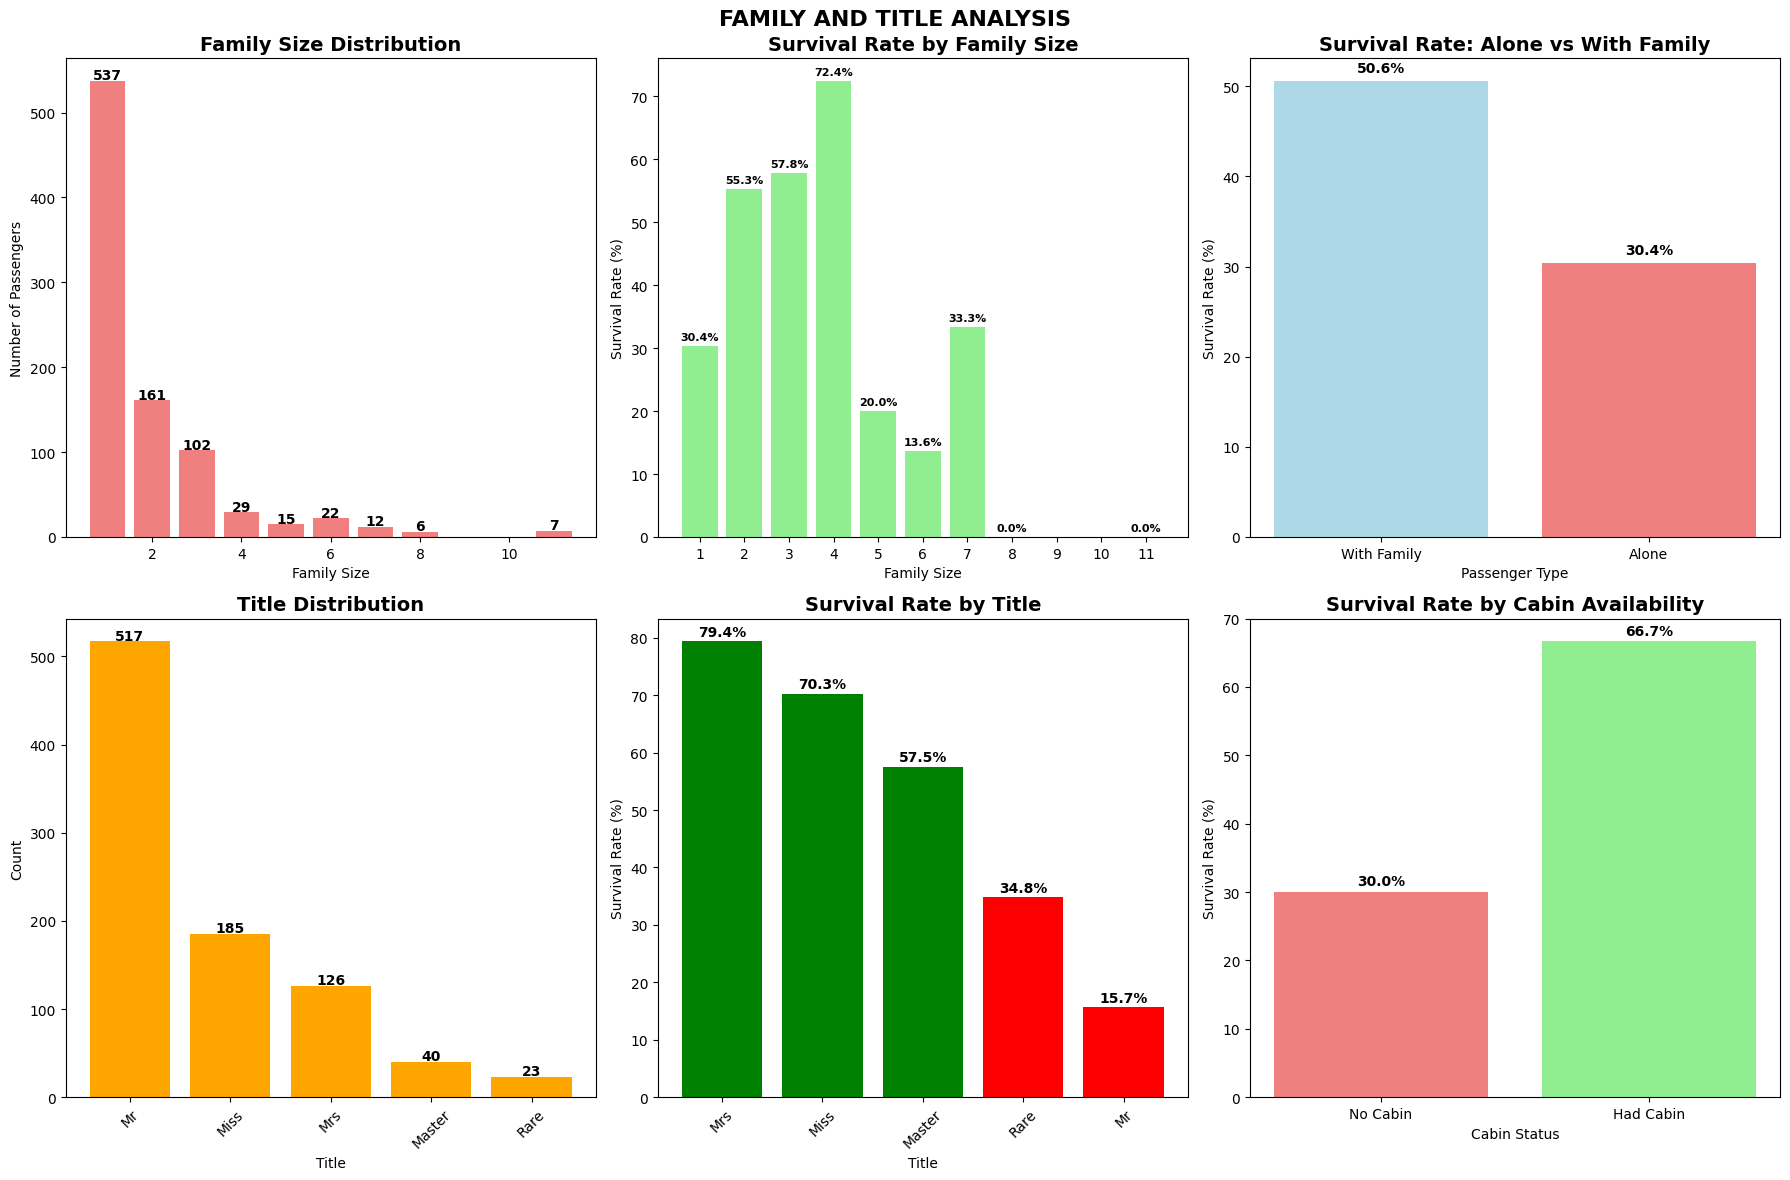


📊 Optimal family size for survival: 4 (72.41%)
📊 Survival rate - Alone: 30.35%
📊 Survival rate - With Family: 50.56%
📊 Best title for survival: Mrs (79.37%)


In [10]:
# ============================================
# CELL 9: FAMILY AND TITLE ANALYSIS
# ============================================
print("="*60)
print("FAMILY SIZE AND TITLE ANALYSIS")
print("="*60)

# SCREENSHOT 5: Family and Title Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Family size distribution
ax1 = axes[0, 0]
family_counts = df_clean['Family_Size'].value_counts().sort_index()
bars = ax1.bar(family_counts.index, family_counts.values, color='lightcoral')
ax1.set_title('Family Size Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Family Size')
ax1.set_ylabel('Number of Passengers')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', fontweight='bold')

# Family size survival
ax2 = axes[0, 1]
family_survival = df_clean.groupby('Family_Size')['Survived'].mean() * 100
bars = ax2.bar(family_survival.index, family_survival.values, color='lightgreen')
ax2.set_title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
ax2.set_xlabel('Family Size')
ax2.set_ylabel('Survival Rate (%)')
ax2.set_xticks(range(1, 12))
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold', fontsize=8)

# Is Alone analysis
ax3 = axes[0, 2]
alone_survival = df_clean.groupby('Is_Alone')['Survived'].mean() * 100
bars = ax3.bar(['With Family', 'Alone'], alone_survival.values, color=['lightblue', 'lightcoral'])
ax3.set_title('Survival Rate: Alone vs With Family', fontsize=14, fontweight='bold')
ax3.set_xlabel('Passenger Type')
ax3.set_ylabel('Survival Rate (%)')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

# Title distribution
ax4 = axes[1, 0]
title_counts = df_clean['Title_Simplified'].value_counts()
bars = ax4.bar(title_counts.index, title_counts.values, color='orange')
ax4.set_title('Title Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Title')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', fontweight='bold')

# Title survival
ax5 = axes[1, 1]
title_survival = df_clean.groupby('Title_Simplified')['Survived'].mean() * 100
title_survival = title_survival.sort_values(ascending=False)
bars = ax5.bar(title_survival.index, title_survival.values,
               color=['green' if x > 50 else 'red' for x in title_survival.values])
ax5.set_title('Survival Rate by Title', fontsize=14, fontweight='bold')
ax5.set_xlabel('Title')
ax5.set_ylabel('Survival Rate (%)')
ax5.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

# Has Cabin analysis
ax6 = axes[1, 2]
cabin_survival = df_clean.groupby('Has_Cabin')['Survived'].mean() * 100
bars = ax6.bar(['No Cabin', 'Had Cabin'], cabin_survival.values, color=['lightcoral', 'lightgreen'])
ax6.set_title('Survival Rate by Cabin Availability', fontsize=14, fontweight='bold')
ax6.set_xlabel('Cabin Status')
ax6.set_ylabel('Survival Rate (%)')
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', fontweight='bold')

plt.suptitle('FAMILY AND TITLE ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Optimal family size for survival: {family_survival.idxmax()} ({family_survival.max():.2f}%)")
print(f"📊 Survival rate - Alone: {alone_survival[1]:.2f}%")
print(f"📊 Survival rate - With Family: {alone_survival[0]:.2f}%")
print(f"📊 Best title for survival: {title_survival.index[0]} ({title_survival.iloc[0]:.2f}%)")

CORRELATION ANALYSIS


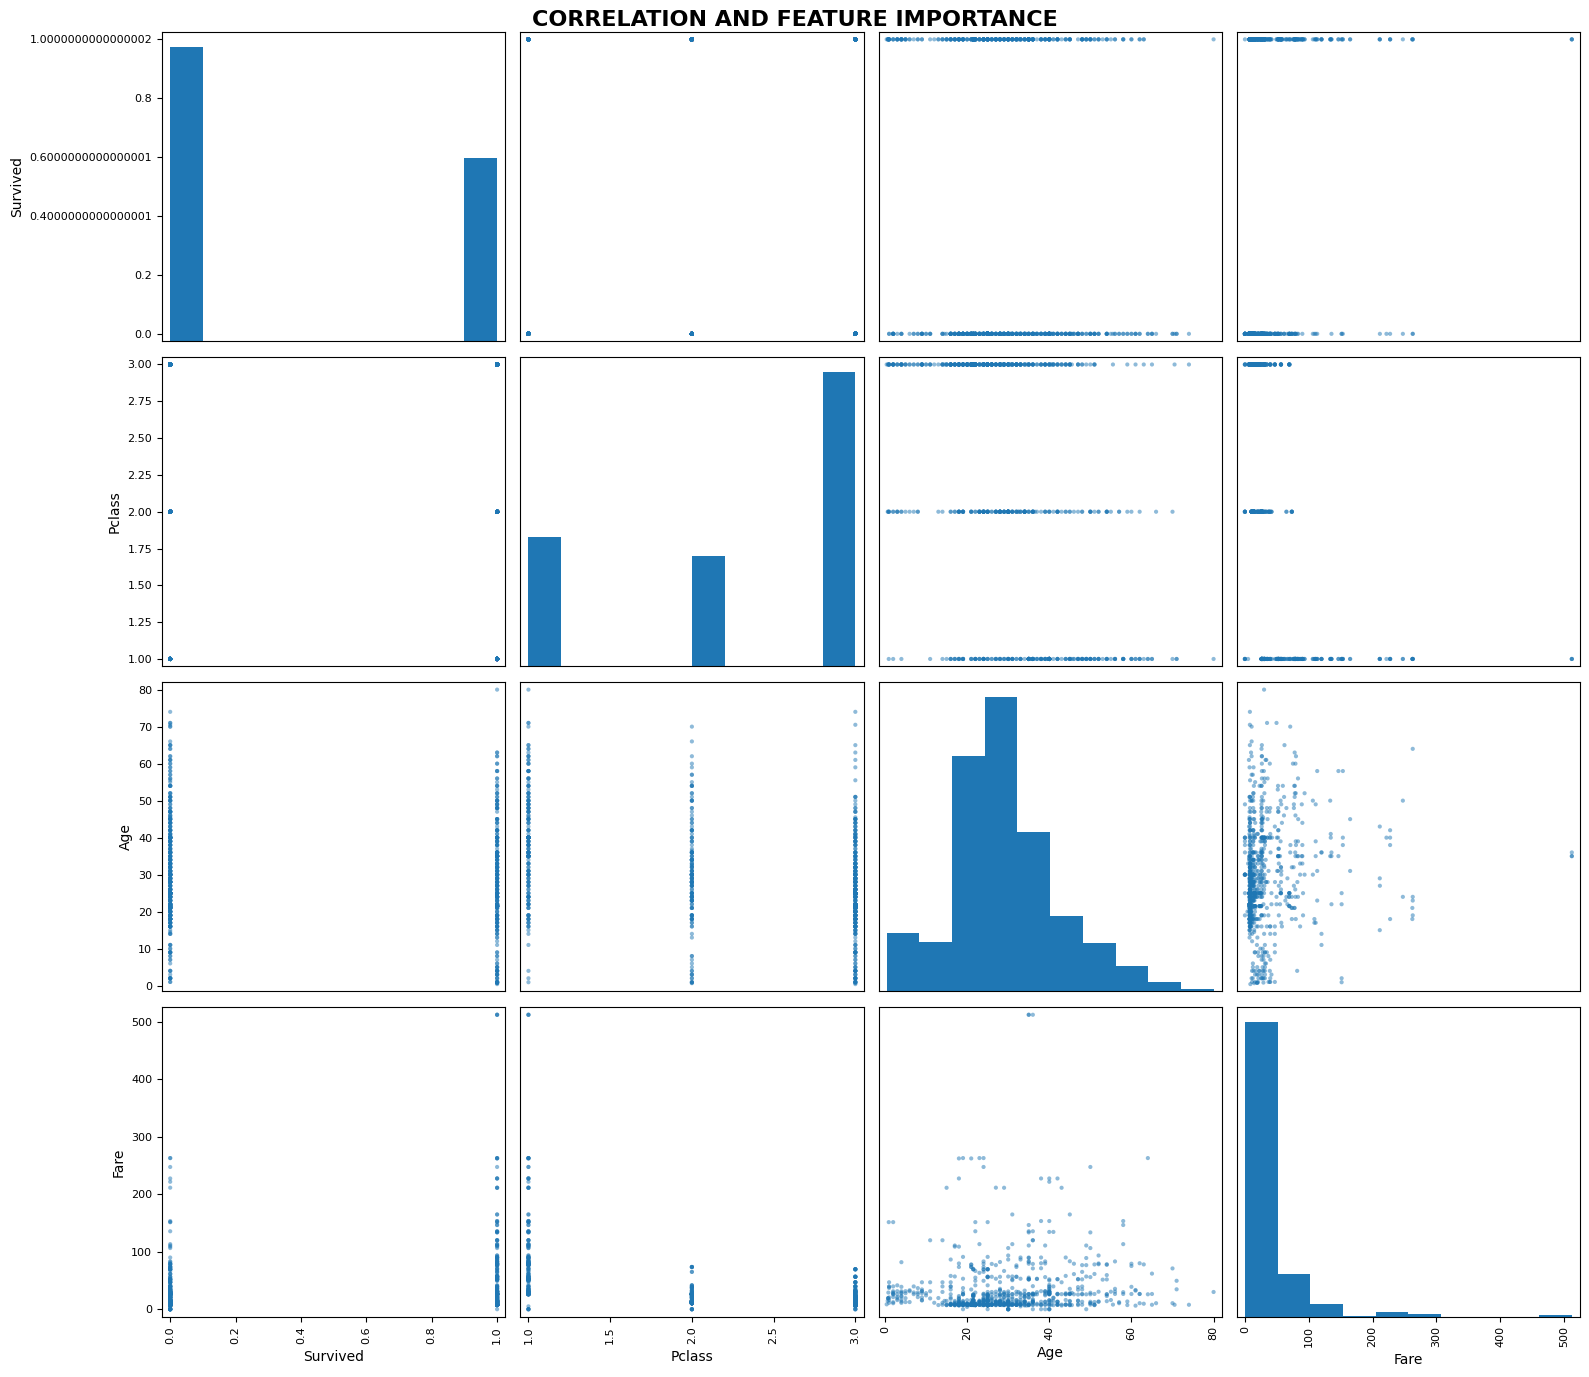


📊 TOP 3 FEATURES AFFECTING SURVIVAL:
   1. Has_Cabin: 0.317
   2. Fare: 0.257
   3. Parch: 0.082


In [11]:
# ============================================
# CELL 10: CORRELATION AND HEATMAPS
# ============================================
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# SCREENSHOT 6: Correlation Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Prepare numeric data for correlation
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Has_Cabin']
corr_data = df_clean[numeric_cols]

# Main correlation heatmap
ax1 = axes[0, 0]
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# Correlation with survival
ax2 = axes[0, 1]
survival_corr = corr_matrix['Survived'].drop('Survived').sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in survival_corr.values]
bars = ax2.barh(survival_corr.index, survival_corr.values, color=colors)
ax2.set_title('Feature Correlation with Survival', fontsize=14, fontweight='bold')
ax2.set_xlabel('Correlation Coefficient')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
for bar, val in zip(bars, survival_corr.values):
    ax2.text(val + 0.02 if val > 0 else val - 0.08, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center')

# Pairplot of key features (simplified)
ax3 = axes[1, 0]
from pandas.plotting import scatter_matrix
scatter_matrix(df_clean[['Survived', 'Pclass', 'Age', 'Fare']], alpha=0.5,
               figsize=(10, 10), diagonal='hist', ax=ax3)
ax3.set_title('Scatter Matrix of Key Features', fontsize=14, fontweight='bold')
# This creates its own figure, so we need to adjust

# Actually, let's do a grouped bar chart for feature importance
ax4 = axes[1, 1]
feature_importance = abs(survival_corr).sort_values(ascending=True)
bars = ax4.barh(feature_importance.index, feature_importance.values, color='skyblue')
ax4.set_title('Absolute Correlation with Survival', fontsize=14, fontweight='bold')
ax4.set_xlabel('|Correlation Coefficient|')
for bar, val in zip(bars, feature_importance.values):
    ax4.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.suptitle('CORRELATION AND FEATURE IMPORTANCE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 TOP 3 FEATURES AFFECTING SURVIVAL:")
print(f"   1. {survival_corr.index[0]}: {survival_corr.values[0]:.3f}")
print(f"   2. {survival_corr.index[1]}: {survival_corr.values[1]:.3f}")
print(f"   3. {survival_corr.index[2]}: {survival_corr.values[2]:.3f}")

In [12]:
# ============================================
# CELL 11: FINAL INSIGHTS AND SUMMARY
# ============================================
print("="*70)
print("🎯 FINAL INSIGHTS AND EXECUTIVE SUMMARY")
print("="*70)

# Calculate all key metrics
total_passengers = len(df_clean)
total_survived = df_clean['Survived'].sum()
survival_rate = (total_survived / total_passengers) * 100

female_rate = df_clean[df_clean['Sex']=='female']['Survived'].mean() * 100
male_rate = df_clean[df_clean['Sex']=='male']['Survived'].mean() * 100

class1_rate = df_clean[df_clean['Pclass']==1]['Survived'].mean() * 100
class2_rate = df_clean[df_clean['Pclass']==2]['Survived'].mean() * 100
class3_rate = df_clean[df_clean['Pclass']==3]['Survived'].mean() * 100

child_rate = df_clean[df_clean['Age']<18]['Survived'].mean() * 100
adult_rate = df_clean[df_clean['Age']>=18]['Survived'].mean() * 100

alone_rate = df_clean[df_clean['Is_Alone']==1]['Survived'].mean() * 100
family_rate = df_clean[df_clean['Is_Alone']==0]['Survived'].mean() * 100

# Create summary DataFrame
summary_data = {
    'Category': ['Overall Survival', 'Gender - Female', 'Gender - Male',
                 'Class - 1st', 'Class - 2nd', 'Class - 3rd',
                 'Age - Children (<18)', 'Age - Adults (18+)',
                 'Traveling - Alone', 'Traveling - With Family'],
    'Survival Rate (%)': [survival_rate, female_rate, male_rate,
                          class1_rate, class2_rate, class3_rate,
                          child_rate, adult_rate, alone_rate, family_rate],
    'Count': [total_passengers,
              len(df_clean[df_clean['Sex']=='female']),
              len(df_clean[df_clean['Sex']=='male']),
              len(df_clean[df_clean['Pclass']==1]),
              len(df_clean[df_clean['Pclass']==2]),
              len(df_clean[df_clean['Pclass']==3]),
              len(df_clean[df_clean['Age']<18]),
              len(df_clean[df_clean['Age']>=18]),
              len(df_clean[df_clean['Is_Alone']==1]),
              len(df_clean[df_clean['Is_Alone']==0])]
}

summary_df = pd.DataFrame(summary_data)
print("\n📊 SUMMARY TABLE:")
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("🔍 KEY FINDINGS:")
print("="*70)

print(f"""
1. GENDER DISPARITY:
   → Women were {female_rate/male_rate:.1f}x more likely to survive than men
   → {female_rate:.1f}% of women survived vs only {male_rate:.1f}% of men
   → This reflects the "women and children first" protocol

2. CLASS PRIVILEGE:
   → 1st class passengers had {class1_rate/class3_rate:.1f}x higher survival than 3rd class
   → {class1_rate:.1f}% of 1st class survived vs only {class3_rate:.1f}% of 3rd class
   → Upper classes had better access to lifeboats

3. AGE FACTORS:
   → Children had {child_rate/adult_rate:.1f}x higher survival than adults
   → {child_rate:.1f}% of children survived vs {adult_rate:.1f}% of adults
   → Priority given to children

4. FAMILY MATTERS:
   → Passengers with family had {family_rate/alone_rate:.1f}x higher survival
   → {family_rate:.1f}% with family survived vs {alone_rate:.1f}% alone
   → Optimal family size: {family_survival.idxmax()} ({family_survival.max():.1f}% survival)

5. WEALTH INDICATORS:
   → Higher fare = higher survival probability
   → Passengers with cabins: {cabin_survival[1]:.1f}% survival
   → Passengers without cabins: {cabin_survival[0]:.1f}% survival

6. TITLES MATTERED:
   → "Mrs" had highest survival ({title_survival['Mrs']:.1f}%)
   → "Mr" had lowest survival ({title_survival['Mr']:.1f}%)
   → "Master" (young boys) had {title_survival['Master']:.1f}% survival
""")

print("="*70)
print("🏆 CONCLUSION:")
print("="*70)
print("""
The Titanic disaster revealed strong social hierarchies:
• Women and children were given priority
• Upper class passengers had significant advantages
• Family units had better survival chances
• Solo travelers were at highest risk

These patterns reflect the social norms and evacuation procedures of 1912,
where lifeboat access was heavily influenced by gender, class, and family status.
""")
print("="*70)

# Save cleaned dataset for later use
df_clean.to_csv('titanic_cleaned.csv', index=False)
print("\n✅ Cleaned dataset saved as 'titanic_cleaned.csv'")

🎯 FINAL INSIGHTS AND EXECUTIVE SUMMARY

📊 SUMMARY TABLE:
               Category  Survival Rate (%)  Count
       Overall Survival          38.383838    891
        Gender - Female          74.203822    314
          Gender - Male          18.890815    577
            Class - 1st          62.962963    216
            Class - 2nd          47.282609    184
            Class - 3rd          24.236253    491
   Age - Children (<18)          53.982301    113
     Age - Adults (18+)          36.118252    778
      Traveling - Alone          30.353818    537
Traveling - With Family          50.564972    354

🔍 KEY FINDINGS:

1. GENDER DISPARITY:
   → Women were 3.9x more likely to survive than men
   → 74.2% of women survived vs only 18.9% of men
   → This reflects the "women and children first" protocol

2. CLASS PRIVILEGE:
   → 1st class passengers had 2.6x higher survival than 3rd class
   → 63.0% of 1st class survived vs only 24.2% of 3rd class
   → Upper classes had better access to lifeb